# Feature Engineering Testing v5 — official test tujuh fitur


## 1. Lokasi dan keberadaan artefak final


In [1]:
from pathlib import Path
import gc, hashlib, json, os, time
import joblib
import numpy as np
import tensorflow as tf
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

SEED = 30092026
RUN_ID = "cifar10_7fitur_v5"
ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / RUN_ID / "fusion"
MODEL_PATH = OUT / "model" / "fusion_v5_final.joblib"
SELECTION_PATH = OUT / "laporan" / "selection.json"
MANIFEST_PATH = OUT / "laporan" / "combination_manifest.json"
VARIANTS = ("rgb", "avg", "ntsc")
CLASS_NAMES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


for path in (MODEL_PATH, SELECTION_PATH, MANIFEST_PATH):
    if not path.is_file():
        raise FileNotFoundError("Artefak fusion final tidak ada: " + str(path))
print("Testing fusion v5:", OUT)


I0000 00:00:1791616967.472891  184410 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791616967.504975  184410 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791616968.304003  184410 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Testing fusion v5: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-7/outputs/cifar10_7fitur_v5/fusion


## 2. Definisi preprocessing identik dengan Training


In [2]:
class GroupPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, boundaries, weights, block_l2=False):
        self.boundaries = boundaries
        self.weights = weights
        self.block_l2 = block_l2

    def fit(self, X, y=None):
        raise RuntimeError("Testing hanya menggunakan preprocessor yang sudah dilatih")

    def transform(self, X):
        if X.shape[1] != self.boundaries_[-1]:
            raise ValueError("Dimensi input salah")
        blocks = []
        for scaler, weight, a, b in zip(
            self.scalers_, self.weights, self.boundaries_[:-1], self.boundaries_[1:]
        ):
            block = scaler.transform(X[:, a:b]).astype(np.float32)
            if self.block_l2:
                block = Normalizer().transform(block)
            blocks.append(block * np.float32(weight))
        return Normalizer().transform(np.concatenate(blocks, axis=1)).astype(np.float32)


## 3. Verifikasi model, seleksi, arsip, dan checkpoint


In [3]:
selection = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
model = joblib.load(MODEL_PATH)
if (
    selection["run_id"] != RUN_ID
    or manifest["run_id"] != RUN_ID
    or model["run_id"] != RUN_ID
    or model["fit_count"] != 50000
    or model["selection_sha256"] != sha256_file(SELECTION_PATH)
    or selection["manifest_sha256"] != sha256_file(MANIFEST_PATH)
    or model["identity_sha256"] != selection["identity_sha256"]
    or model["spec"] != selection["selected"]["spec"]
):
    raise ValueError("Selection, manifest, dan model tidak cocok")
rep = model["spec"]["rep"]
archive_path = OUT / "fitur" / f"train_combined_{rep}.npz"
if (
    not archive_path.is_file()
    or sha256_file(archive_path) != model["source_archive_sha256"]
    or sha256_file(archive_path) != manifest["combined_archive_hashes"][rep]
):
    raise ValueError("Arsip fitur training berubah")
for variant in VARIANTS:
    cnn_path = ROOT / manifest["model_paths"][variant]
    if sha256_file(cnn_path) != manifest["model_hashes"][variant]:
        raise ValueError("Checkpoint CNN berubah: " + variant)
print("Semua sumber final terverifikasi. Representasi:", rep)


Semua sumber final terverifikasi. Representasi: B


## 4. Muat official test setelah konfigurasi diverifikasi


In [4]:
from tensorflow.keras.datasets import cifar10

(_, _), (x_test, y_test) = cifar10.load_data()
y_test = y_test.ravel().astype(np.int64)
if x_test.shape != (10000, 32, 32, 3) or y_test.shape != (10000,):
    raise ValueError("Official test CIFAR-10 tidak sesuai")
print("Official test:", x_test.shape)


Official test: (10000, 32, 32, 3)


## 5. Konversi RGB/AVG/NTSC yang tetap


In [5]:
def prepare_images(x, variant):
    rgb = np.asarray(x, dtype=np.float32) / np.float32(255.0)
    if variant == "rgb":
        return rgb
    if variant == "avg":
        return np.mean(rgb, axis=-1, keepdims=True, dtype=np.float32)
    if variant == "ntsc":
        weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
        return np.sum(rgb * weights, axis=-1, keepdims=True, dtype=np.float32)
    raise ValueError("Varian tidak dikenal: " + variant)


## 6. Ekstraksi CNN test satu model setiap kali


In [6]:
cnn_features = {}
cnn_features_B = {}
for variant in VARIANTS:
    cnn_path = ROOT / manifest["model_paths"][variant]
    cnn = tf.keras.models.load_model(cnn_path, compile=False)
    extractor = tf.keras.Model(cnn.input, cnn.get_layer("embedding").output)
    if int(extractor.output.shape[-1]) != 512:
        raise ValueError("Embedding bukan 512: " + variant)
    result = np.empty((10000, 512), np.float32)
    result_B = np.empty((10000, 512), np.float32)
    for begin in range(0, 10000, 128):
        end = min(begin + 128, 10000)
        batch = prepare_images(x_test[begin:end], variant)
        original = extractor(batch, training=False).numpy().astype(np.float32)
        flipped = (
            extractor(np.ascontiguousarray(batch[:, :, ::-1, :]), training=False)
            .numpy()
            .astype(np.float32)
        )
        averaged = (original + flipped) * np.float32(0.5)
        result_B[begin:end] = averaged
        result[begin:end] = averaged if rep == "B" else original
        if end % 2560 == 0 or end == 10000:
            print(variant, end, "/10000", flush=True)
    if not np.isfinite(result).all() or not np.isfinite(result_B).all():
        raise ValueError("Fitur CNN test nonfinite: " + variant)
    cnn_features[variant] = result
    cnn_features_B[variant] = result_B
    del extractor, cnn
    tf.keras.backend.clear_session()
    gc.collect()
print("Tiga CNN test selesai; embedding B tersedia untuk SVM standalone")


I0000 00:00:1791616971.016568  184410 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4139 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


I0000 00:00:1791616971.961704  184410 cuda_dnn.cc:461] Loaded cuDNN version 92600


rgb 2560 /10000


rgb 5120 /10000


rgb 7680 /10000


...

ntsc 2560 /10000


ntsc 5120 /10000


ntsc 7680 /10000


ntsc 10000 /10000


Tiga CNN test selesai; embedding B tersedia untuk SVM standalone


## 7. Definisi empat descriptor manual yang tetap


In [7]:
def handcrafted_descriptors(x, batch_size=128, verbose=1):
    # HOG: 9 orientasi unsigned, cell 8x8, block 2x2, L2 per block.
    # LBP: 8 tetangga radius 1, histogram 256 kode.
    # HSV: 16 bin per kanal. Statistik RGB: mean, std, skewness per kanal.
    import matplotlib.colors as mcolors

    outputs = {k: [] for k in ("hog", "lbp", "hsv", "rgb_stats")}
    total_batches = int(np.ceil(len(x) / batch_size))
    progress_interval = max(1, total_batches // 20)
    for begin in range(0, len(x), batch_size):
        rgb = np.asarray(x[begin : begin + batch_size], dtype=np.float32) / 255.0
        gray = np.sum(rgb * np.array([0.299, 0.587, 0.114], np.float32), axis=-1)
        gy, gx = np.gradient(gray, axis=(1, 2))
        magnitude = np.sqrt(gx * gx + gy * gy)
        orientation = np.mod(np.arctan2(gy, gx) * (180.0 / np.pi), 180.0)
        bins = np.minimum((orientation / 20.0).astype(np.int32), 8)
        cell_hist = np.zeros((len(rgb), 4, 4, 9), dtype=np.float32)
        for row in range(4):
            for col in range(4):
                b = bins[:, row * 8 : (row + 1) * 8, col * 8 : (col + 1) * 8]
                m = magnitude[:, row * 8 : (row + 1) * 8, col * 8 : (col + 1) * 8]
                for angle in range(9):
                    cell_hist[:, row, col, angle] = np.sum(
                        m * (b == angle), axis=(1, 2)
                    )
        blocks = []
        for row in range(3):
            for col in range(3):
                block = cell_hist[:, row : row + 2, col : col + 2, :].reshape(
                    len(rgb), -1
                )
                denominator = np.maximum(
                    np.linalg.norm(block, axis=1, keepdims=True), 1e-8
                )
                blocks.append(block / denominator)
        outputs["hog"].append(np.concatenate(blocks, axis=1))
        padded = np.pad(gray, ((0, 0), (1, 1), (1, 1)), mode="edge")
        lbp = np.zeros(gray.shape, dtype=np.uint8)
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]
        for bit, (dy, dx) in enumerate(offsets):
            neighbor = padded[:, 1 + dy : 33 + dy, 1 + dx : 33 + dx]
            lbp |= (neighbor >= gray).astype(np.uint8) << bit
        hist = np.zeros((len(rgb), 256), dtype=np.float32)
        np.add.at(hist, (np.repeat(np.arange(len(rgb)), 1024), lbp.reshape(-1)), 1)
        outputs["lbp"].append(hist / 1024.0)
        hsv = mcolors.rgb_to_hsv(rgb)
        hsv_hist = np.zeros((len(rgb), 3, 16), dtype=np.float32)
        for channel in range(3):
            hsv_bin = np.minimum((hsv[..., channel] * 16).astype(np.int32), 15)
            np.add.at(
                hsv_hist[:, channel, :],
                (np.repeat(np.arange(len(rgb)), 1024), hsv_bin.reshape(-1)),
                1,
            )
        outputs["hsv"].append(hsv_hist.reshape(len(rgb), -1) / 1024.0)
        flat = rgb.reshape(len(rgb), -1, 3)
        mean = flat.mean(axis=1)
        std = flat.std(axis=1)
        skew = np.mean(
            ((flat - mean[:, None, :]) / np.maximum(std[:, None, :], 1e-6)) ** 3, axis=1
        )
        outputs["rgb_stats"].append(np.concatenate((mean, std, skew), axis=1))
        batch_number = begin // batch_size + 1
        if verbose == 1 and (
            batch_number % progress_interval == 0 or batch_number == total_batches
        ):
            processed = min(begin + batch_size, len(x))
            print(f"Descriptor: {processed}/{len(x)} gambar", flush=True)
    result = {
        key: np.concatenate(parts).astype(np.float32) for key, parts in outputs.items()
    }
    assert [result[k].shape[1] for k in ("hog", "lbp", "hsv", "rgb_stats")] == [
        324,
        256,
        48,
        9,
    ]
    assert all(np.isfinite(value).all() for value in result.values())
    return result


## 8. Hitung empat descriptor pada official test


In [8]:
desc = handcrafted_descriptors(x_test, batch_size=128, verbose=1)
manual = np.concatenate(
    [desc[k] for k in ("hog", "lbp", "hsv", "rgb_stats")], axis=1
).astype(np.float32)
if manual.shape != (10000, 637) or not np.isfinite(manual).all():
    raise ValueError("Descriptor manual test tidak valid")
print("Empat descriptor test:", manual.shape)


Descriptor: 384/10000 gambar


Descriptor: 768/10000 gambar


Descriptor: 1152/10000 gambar


Descriptor: 1536/10000 gambar


Descriptor: 1920/10000 gambar


...

Descriptor: 9216/10000 gambar


Descriptor: 9600/10000 gambar


Descriptor: 9984/10000 gambar


Descriptor: 10000/10000 gambar


Empat descriptor test: (10000, 637)


## 9. Gabungkan tujuh kelompok fitur test


In [9]:
X_test = np.concatenate([cnn_features[v] for v in VARIANTS] + [manual], axis=1).astype(
    np.float32
)
if X_test.shape != (10000, 2173) or not np.isfinite(X_test).all():
    raise ValueError("Matriks tujuh fitur test tidak valid")
print("Matriks tujuh fitur:", X_test.shape)


Matriks tujuh fitur: (10000, 2173)


## 10. Prediksi dengan SVM final yang dibekukan


In [10]:
pred = model["pipeline"].predict(X_test)
if pred.shape != (10000,) or not np.isin(pred, np.arange(10)).all():
    raise ValueError("Prediksi final tidak valid")
print("Prediksi official test selesai:", len(pred))


Prediksi official test selesai: 10000


## Prediksi SVM standalone RGB, AVG, dan NTSC


In [11]:
standalone_predictions = {}
standalone_svm_hashes = {}
for variant in VARIANTS:
    svm_path = ROOT / "outputs" / RUN_ID / variant / "model" / "svm.joblib"
    if not svm_path.is_file():
        raise FileNotFoundError("SVM standalone belum tersedia: " + str(svm_path))
    standalone_model = joblib.load(svm_path)
    if (
        standalone_model.get("run_id") != RUN_ID
        or standalone_model.get("cnn_sha256") != manifest["model_hashes"][variant]
        or standalone_model.get("fit_count") != 50000
        or standalone_model.get("representation") != "B"
    ):
        raise ValueError("SVM standalone tidak cocok dengan CNN: " + variant)
    variant_predictions = standalone_model["pipeline"].predict(cnn_features_B[variant])
    if (
        variant_predictions.shape != (10000,)
        or not np.isin(variant_predictions, np.arange(10)).all()
    ):
        raise ValueError("Prediksi standalone tidak valid: " + variant)
    standalone_predictions[variant] = variant_predictions
    standalone_svm_hashes[variant] = sha256_file(svm_path)
    print("Prediksi SVM standalone selesai:", variant, flush=True)
    del standalone_model


Prediksi SVM standalone selesai: rgb


Prediksi SVM standalone selesai: avg


Prediksi SVM standalone selesai: ntsc


## 11. Hitung metrik dan status target 95%


In [12]:
correct = int(np.sum(y_test == pred))
accuracy = float(accuracy_score(y_test, pred))
macro_f1 = float(f1_score(y_test, pred, average="macro"))
report_dict = classification_report(
    y_test, pred, target_names=CLASS_NAMES, output_dict=True
)
cm = confusion_matrix(y_test, pred)
print(classification_report(y_test, pred, target_names=CLASS_NAMES))
print(
    "Official test:",
    correct,
    "/10000 =",
    f"{accuracy:.2%}",
    "| target:",
    "TERCAPAI" if correct >= 9500 else "BELUM TERCAPAI",
)
print("Post-exposure testing: official test sudah dipakai pada eksperimen v1–v4")


              precision    recall  f1-score   support

    airplane       0.96      0.97      0.96      1000
  automobile       0.97      0.98      0.98      1000
        bird       0.94      0.94      0.94      1000
         cat       0.89      0.88      0.89      1000
        deer       0.94      0.96      0.95      1000
         dog       0.92      0.91      0.92      1000
        frog       0.97      0.96      0.97      1000
       horse       0.98      0.97      0.98      1000
        ship       0.98      0.97      0.97      1000
       truck       0.97      0.97      0.97      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000

Official test: 9520 /10000 = 95.20% | target: TERCAPAI
Post-exposure testing: official test sudah dipakai pada eksperimen v1–v4


## Tabel perbandingan akurasi empat model pada official test


In [13]:
comparison_rows = []
for variant in VARIANTS:
    correct_variant = int(np.sum(standalone_predictions[variant] == y_test))
    comparison_rows.append(
        {
            "model": variant.upper() + " CNN + SVM",
            "correct": correct_variant,
            "accuracy": correct_variant / len(y_test),
        }
    )
comparison_rows.append(
    {
        "model": "Feature Engineering (7 fitur) + SVM",
        "correct": correct,
        "accuracy": accuracy,
    }
)
print(f"{'Model':<42} {'Benar / 10000':>15} {'Akurasi':>12}")
print("-" * 73)
for row in comparison_rows:
    print(f"{row['model']:<42} {row['correct']:>15} {row['accuracy']:>11.2%}")
print(
    "Seluruh angka menggunakan official test CIFAR-10 yang sama; "
    "perbandingan ini tidak dipakai untuk memilih model."
)
comparison_path = OUT / "laporan" / "accuracy_comparison.json"
comparison_report = {
    "run_id": RUN_ID,
    "test_count": len(y_test),
    "rows": comparison_rows,
    "fusion_model_sha256": sha256_file(MODEL_PATH),
    "selection_sha256": sha256_file(SELECTION_PATH),
    "standalone_svm_sha256": standalone_svm_hashes,
    "post_exposure_testing": True,
}
if comparison_path.exists():
    previous = json.loads(comparison_path.read_text(encoding="utf-8"))
    if (
        previous.get("fusion_model_sha256") != comparison_report["fusion_model_sha256"]
        or previous.get("standalone_svm_sha256") != standalone_svm_hashes
    ):
        raise ValueError("Tabel akurasi sebelumnya memakai model berbeda")
temporary = comparison_path.with_suffix(".json.tmp")
temporary.write_text(
    json.dumps(comparison_report, ensure_ascii=False, indent=2), encoding="utf-8"
)
os.replace(temporary, comparison_path)
print("Tabel disimpan:", comparison_path)


Model                                        Benar / 10000      Akurasi
-------------------------------------------------------------------------
RGB CNN + SVM                                         9476      94.76%
AVG CNN + SVM                                         9300      93.00%
NTSC CNN + SVM                                        9277      92.77%
Feature Engineering (7 fitur) + SVM                   9520      95.20%
Seluruh angka menggunakan official test CIFAR-10 yang sama; perbandingan ini tidak dipakai untuk memilih model.
Tabel disimpan: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-7/outputs/cifar10_7fitur_v5/fusion/laporan/accuracy_comparison.json


## Diagram perbandingan akurasi empat model


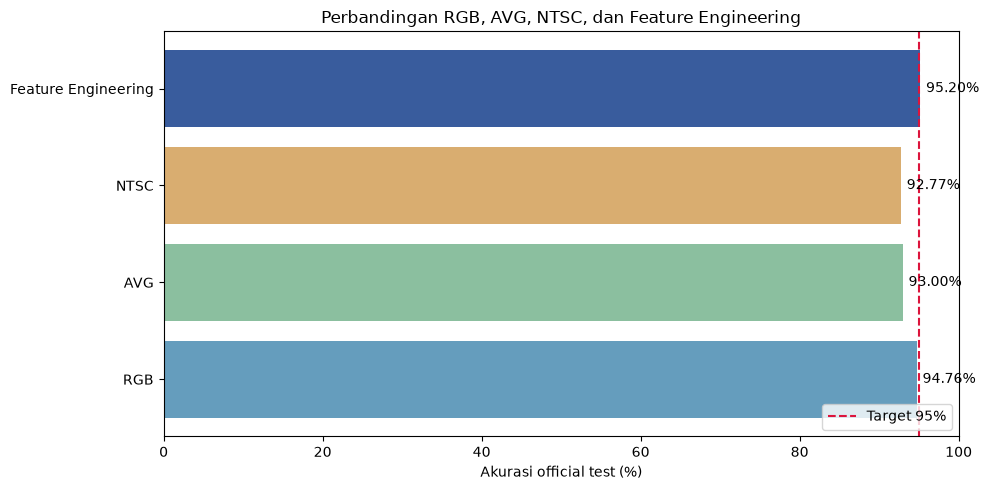

Diagram disimpan: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-7/outputs/cifar10_7fitur_v5/fusion/laporan/accuracy_comparison.png


In [14]:
labels = [
    row["model"]
    .replace(" CNN + SVM", "")
    .replace("Feature Engineering (7 fitur) + SVM", "Feature Engineering")
    for row in comparison_rows
]
values = [row["accuracy"] * 100 for row in comparison_rows]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values, color=("#659dbd", "#8bbf9f", "#d9ad70", "#395c9d"))
ax.set_xlim(0, 100)
ax.axvline(95, color="crimson", linestyle="--", linewidth=1.5, label="Target 95%")
ax.set_xlabel("Akurasi official test (%)")
ax.set_title("Perbandingan RGB, AVG, NTSC, dan Feature Engineering")
ax.bar_label(bars, labels=[f"{value:.2f}%" for value in values], padding=4)
ax.legend(loc="lower right")
fig.tight_layout()
comparison_plot_path = OUT / "laporan" / "accuracy_comparison.png"
fig.savefig(comparison_plot_path, dpi=150)
plt.show()
print("Diagram disimpan:", comparison_plot_path)


## 12. Simpan laporan dan prediksi per sampel


In [15]:
metrics_path = OUT / "laporan" / "test_metrics.json"
predictions_path = OUT / "laporan" / "test_predictions.npz"
report = {
    "run_id": RUN_ID,
    "model_sha256": sha256_file(MODEL_PATH),
    "selection_sha256": sha256_file(SELECTION_PATH),
    "representation": rep,
    "groups": "all7",
    "correct": correct,
    "total": 10000,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "target_accuracy": 0.95,
    "target_reached": correct >= 9500,
    "post_exposure_testing": True,
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist(),
}
if metrics_path.exists():
    old = json.loads(metrics_path.read_text(encoding="utf-8"))
    if (
        old["model_sha256"] != report["model_sha256"]
        or old["selection_sha256"] != report["selection_sha256"]
    ):
        raise ValueError("Laporan test lama memakai model berbeda")
temporary = metrics_path.with_suffix(".json.tmp")
temporary.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
os.replace(temporary, metrics_path)
if predictions_path.exists():
    with np.load(predictions_path, allow_pickle=False) as old:
        if str(old["model_sha256"]) != report["model_sha256"]:
            raise ValueError("Prediksi lama memakai model berbeda")
with predictions_path.open("wb") as stream:
    np.savez_compressed(
        stream,
        indices=np.arange(10000),
        y_true=y_test,
        y_pred=pred,
        model_sha256=report["model_sha256"],
    )
print("Metrik:", metrics_path, "| prediksi:", predictions_path)


Metrik: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-7/outputs/cifar10_7fitur_v5/fusion/laporan/test_metrics.json | prediksi: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-7/outputs/cifar10_7fitur_v5/fusion/laporan/test_predictions.npz


## 13. Visualisasi confusion matrix


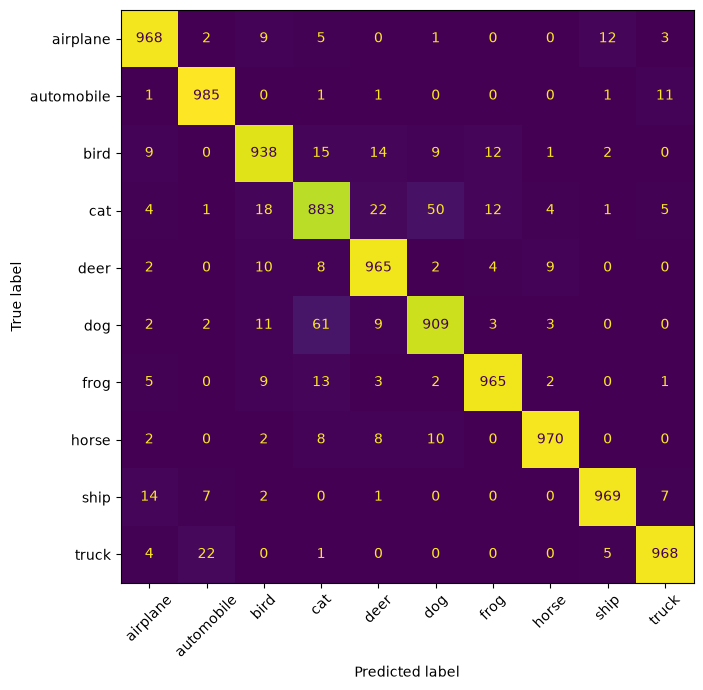

Grafik: /home/saga/anaconda3/envs/envGPU/BDA_Project/tugas-7/outputs/cifar10_7fitur_v5/fusion/laporan/confusion_matrix.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, xticks_rotation=45, colorbar=False
)
fig.tight_layout()
plot_path = OUT / "laporan" / "confusion_matrix.png"
fig.savefig(plot_path, dpi=150)
plt.show()
print("Grafik:", plot_path)
